In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
# import sys
# sys.path.append('..')
from CRM import CRM
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
import json
import pickle
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import scipy.stats as st
from pathlib import Path

In [2]:
def numerical_error(N):
    return N[-1, :].max() > 1e3

def has_converged(N):
    return np.abs((N[-1,:]-N[-10, :])/N[-1, :]).max() < 1e-3

def richness(N, min_value = 1e-4):
    return np.sum(N[-1, :]>min_value)

# def has_converged_transfer(N, transfer_time, dt):
    

# ToDo - Parameter swipe leakage rates and variability in C?

# Description
This notebook is used to get an intuition about what to expect for the 4 species communnity assembly

## Define parameters
$J^{in}_{i\alpha} = C_{i\alpha}\frac{R_{\alpha}}{R_{\alpha} + K_{i\alpha}}$

$\frac{dN_i}{dt} = g_iN_i  \left[ \sum_{\alpha}w_{\alpha}(1-l_{\alpha})J^{in}_{i\alpha} -m_i\right] -N_id$

$\frac{dR_{\alpha}}{dt} = (R^0_{\alpha}-R_{\alpha})d-\sum_i N_iJ^{in}_{i\alpha} + \sum_{i, \beta}D_{i\alpha\beta}\frac{w_{\beta}}{w_{\alpha}}l_{\beta}N_iJ^{in}_{i\beta}$


# Simplified
$J^{in}_{i\alpha} = C_{i\alpha}\frac{R_{\alpha}}{R_{\alpha} + K_{i\alpha}}$

$\frac{dN_i}{dt} = N_i (1-l) \sum_{\alpha}J^{in}_{i\alpha} -N_id$

$\frac{dR_{\alpha}}{dt} = (R^0_{\alpha}-R_{\alpha})d-\sum_i N_iJ^{in}_{i\alpha} + l\sum_{i, \beta}D_{i\alpha\beta}N_iJ^{in}_{i\beta}$


| Symbol |    Description                                                           | Value   |
|-----|-----------------------------------------------------------------------------|---|
| $N_i$  | population density of species i (individuals/volume)                        |   |
| $R_{\alpha}$  | Concentration of resource α (mass/volume)                                   |   |
| $C_{i\alpha}$ | Maximum uptake rate of resource α by species i (mass/individual/time) |   |
| $D_{\alpha\beta}$ | Fraction of byproducts from resource β converted to α (unitless)            |   |
| $g_i$  | Conversion factor from energy uptake to growth rate (1/energy)              |   |
| $w_{\alpha}$  | Energy content of resource α (energy/mass)                                  |   |
| $l_{\alpha}$  | Leakage fraction for resource α (unitless)                                  | 0.1  |
| $m_i$  | Minimal energy uptake for maintenance of species i (energy/time)            |   |
| $d$  | Dilution rate  (1/time)           |   |


| Symbol |    Description                                                           | Value   |
|-----|-----------------------------------------------------------------------------|---|
| $N_i$  | population density of species i (individuals/volume)                        |   |
| $R_{\alpha}$  | Concentration of resource α (mass/volume)                                   |   |
| $C_{i\alpha}$ | Maximum uptake rate of resource α by species i (mass/individual/time) | Scaled so max(C) is 1  |
| $D_{\alpha\beta}$ | Fraction of byproducts from resource β converted to α (unitless)            |   |
| $l_{\alpha}$  | Leakage fraction for resource α (unitless)                                  | 0.1  |
| $d$  | Dilution rate  (1/time)           |  0.1 |


In [3]:
n_species = 4
n_cs = 5

In [23]:
# Default values
g = np.ones(n_species) # Converstion factor per species i from energy uptake to growth rate
m =  np.zeros(n_species) # Minimal energy requirement for maintenance
l = 0.2*np.ones(n_species) # Leakage fractions
K = 1e-3*np.ones(n_cs) # Consider making this small
w = np.ones(n_cs) # All metabolites have the same energy

In [24]:
N0 = [1e-4, 1e-4, 1e-4, 1e-4] # List of initial population densities
R0 = np.zeros(n_cs) # Concentration of resources at t=0, (mass/volume)
R0[0] = 10


## Define uptake rate matrix C
- Check what is the best way to do this (specialist, generalist etc)
- Currently it is just a random number drawn from U(0,1)

In [25]:
C = np.random.uniform(0,1, (n_species, n_cs))

# Define fraction of resource b converted into resource a
- For now, make it identical for all metabolites for all species (i.e. leakage is not determined by the the nutrient only by the species identity)
- Draw from lognormal distribution, but scale it so that it sums to 1

In [26]:
D  = np.random.lognormal(0, 1, size = (n_species, n_cs, n_cs))
for i in range(n_species):
    D[i,:,:] = D[i,:,:]/D[i, :,:].sum(axis = 0)
D = np.transpose(D, (0, 2, 1))

(array([ 16.,  56., 120., 186., 235., 191., 137.,  41.,  14.,   4.]),
 array([-2.4169606 , -2.1659895 , -1.91501839, -1.66404729, -1.41307618,
        -1.16210508, -0.91113397, -0.66016287, -0.40919176, -0.15822066,
         0.09275045]),
 <BarContainer object of 10 artists>)

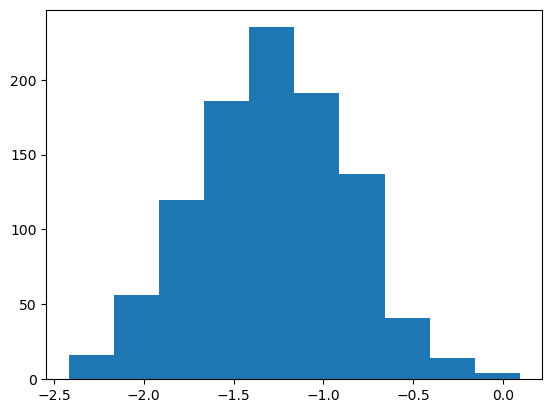

In [27]:
C = st.gamma.rvs(1.2, 0.01, 0.16, size = (10, 10))
D = st.lognorm.rvs(0.41, loc = -1.3, size = (3, 10, 30))
# Values based on fit of e. coli rates
D = st.lognorm.rvs(0.95, 2e-06, 0.05, size = (10,10,10))
# D
plt.hist(np.log10(D.flatten()))

# Test Run

3
None
Function evaluations
221
[0.43089296 0.57949687 0.33454536 0.15441737] [0.13533528 0.13533528 0.13533528 0.13533528]
False
[[2.18948723e-01 9.88154400e+00 5.15115334e-04 0.00000000e+00]
 [2.18948723e-01 9.88154400e+00 5.15115334e-04 0.00000000e+00]]
3


/var/folders/h6/4b_zz_cd5d92w2ycp017ytn00000gp/T/ipykernel_75105/1663318120.py:5: RuntimeWarning: invalid value encountered in divide
  return np.abs((N[-1,:]-N[-10, :])/N[-1, :]).max() < 1e-3


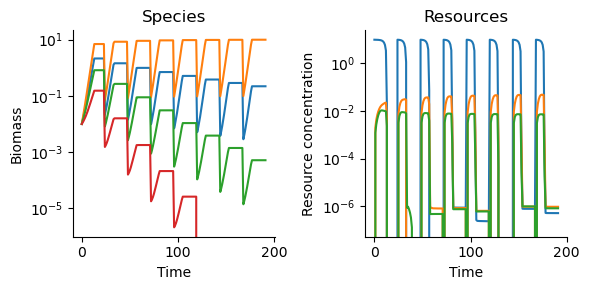

In [28]:
R0 = np.zeros(n_cs) # Concentration of resources at t=0, (mass/volume)
R0[0]=10
N0 = np.ones(n_species)*1e-2
# np.random.seed(0)
# C = np.random.uniform(0.1,0.9, (n_species, n_cs))
# C0 = (np.random.uniform(0,1, size = (n_species, n_cs))>0.1).astype(int)
# C0 = np.ones((n_species, n_cs))
# C0[0,1] = 0
# C0[1,2] = 0
# C0[2,3] = 0
# # C0[3,4] = 0

# C = C*C0
C = np.zeros((n_species, n_cs))
while C[:, 0].max()<0.2:
    # C = np.random.lognormal(0, 1, (n_species, n_cs))
    C = st.gamma.rvs(1.2, 0.01, 0.16, size = (n_species, n_cs))

    C = (C.T/C.sum(axis=1)).T # This normalization is extremely efficient for enabling coexistence with only one byproduct and one resource
    C = C/C.max()


# D  = np.random.uniform(0, 1, size = (n_species, n_cs, n_cs))
# loc=-1.3273421254847004, scale=0.41076857002652306)
# D = st.lognorm(-1.3, 0.41, size = (n_species, n_cs, n_cs))
# Values based on fit of e. coli rates
D = st.lognorm.rvs(0.95, 2e-06, 0.05, size = (n_species, n_cs, n_cs))

for i in range(n_cs):
    D[:,i,i] = 0
for i in range(n_species):
    D[i,:,:] = D[i,:,:]/D[i, :,:].sum(axis = 0)
D = np.transpose(D, (0, 2, 1))
print(len(K))

K = np.random.lognormal(-2, 0, (n_species, n_cs))
# K[:,0] = 1

c = CRM(n_species, n_cs, C, D = D, dilution_rate=0.1, l = l, K = K, R_in = None)
print(c.R_in)
time = 24
# time = 200
# sol = c.run(time, N0, R0, dt = 0.1, method = 'BDF')
fig, [ax1, ax2] = plt.subplots(1,2, figsize = (6, 3))
sol = c.run_transfers(time, N0,R0, dt = 1, transfer_dilution=100, n_transfers=8, method='BDF')
ax1.semilogy(c.N)

# plt.legend()
print('Function evaluations')
print(sol.nfev)
ax2.semilogy(c.R)
print(C[:,0], K[:,0])
print(has_converged(c.N))
print(c.N[-2:, :])
print(richness(c.N))
sns.despine()
ax1.set_xlabel('Time')
ax2.set_xlabel('Time')
ax1.set_ylabel('Biomass')
ax2.set_ylabel('Resource concentration')
ax1.set_title('Species')
ax2.set_title('Resources')
plt.tight_layout()
plt.show()

In [ ]:
u += 1
u = u%4
print(u)
c = CRM(1, n_cs, C[u:u+1,:], D = D[u:u+1,:], dilution_rate=0.1, l = l[u:u+1,:], K = K[u:u+1,:])

# time = 1000
sol = c.run(time, N0[u:u+1], R0, dt = 0.1, method = 'BDF')
plt.semilogy(c.R)

In [ ]:
C

In [ ]:
C[0:1,:].shape

In [ ]:
C[0,:]

# Parameter swipe - # byproducts vs K std

In [42]:
n_cs_arr = np.arange(3, 30, 1)
K_std_arr = np.arange(0, 4.4, 0.2)
K_mean = -1
iterations = 50
l0 = 0.1


In [54]:
final_abundance_matrix = np.zeros((len(n_cs_arr), len(K_std_arr), iterations, 4))
richness_matrix = np.zeros((len(n_cs_arr), len(K_std_arr), iterations))
not_converged = 0
converged = 0
for ic, n_cs in enumerate(n_cs_arr):
    print(ic)
    for j, K_std in enumerate(K_std_arr):
        k = 0
        while k < iterations:
            R0 = np.zeros(n_cs) # Concentration of resources at t=0, (mass/volume)
            R0[0]=10
            l = l0*np.ones(n_species) # Leakage fractions
            N0 = np.ones(n_species)*1e-2
            
            C = np.zeros((n_species, n_cs))
            while C[:, 0].max()<0.2:
                C = np.random.lognormal(0, 1, (n_species, n_cs))
                # C = (C.T/C.sum(axis=1)).T # The existing data is with this line on - toggle off!
                C = C/C.max()


            D  = np.random.uniform(0, 1, size = (n_species, n_cs, n_cs))
            for i in range(n_cs):
                D[:,i,i] = 0
            for i in range(n_species):
                D[i,:,:] = D[i,:,:]/D[i, :,:].sum(axis = 0)
            D = np.transpose(D, (0, 2, 1))            
            K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
            c = CRM(n_species, n_cs, C, D = D, dilution_rate=0.1, l = l, K = K)
            
            time = 1000
            try:
                sol = c.run(time, N0, R0, dt = 0.1, method = 'BDF')
            except ValueError:
                print(f'Error: {K_std}')
                continue
            else:

                if has_converged(c.N) and not numerical_error(c.N):
                    final_abundance_matrix[ic,j,k,:] = c.N[-1,:]
                    richness_matrix[ic,j,k] = richness(c.N)
                    k +=1
                    converged += 1
                else:
                    not_converged += 1
                # print(has_converged(c.N))
                # plt.semilogy(c.N)
                # plt.show()
    break

0


In [48]:
print(converged, not_converged)
has_converged(c.N)

110 26


True

In [ ]:
# with open('K_std_screen_N.npz', 'wb') as f:
#     np.savez(f, final_abundance_matrix)
    

In [4]:
data_folder = Path('../../data/7_CRM')
abundance_matrix = np.load(data_folder / 'parameter_swipe/20240423-235255_final_abundance.npz')['arr_0']
abundance_matrix = np.load(data_folder / 'n_cs_vs_K_parameter_swipe/20240501-014535_final_abundance.npz')['arr_0']

FileNotFoundError: [Errno 2] No such file or directory: '../../data/7_CRM/parameter_swipe/20240423-235255_final_abundance.npz'

In [11]:
richness_matrix = (abundance_matrix > 1e-5).sum(axis=3)

In [13]:
richness_matrix = richness_matrix[:, ::-1,:]

Text(0.5, 1.0, 'Richness on single carbon source with 4 species community')

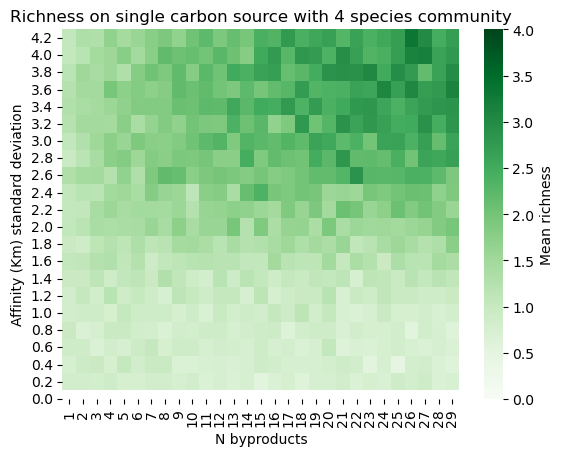

In [16]:
sns.heatmap(richness_matrix.mean(axis=2).T, yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1], cmap='Greens',
            cbar_kws={'label':'Mean richness'}, xticklabels = np.linspace(2, 30, 29, dtype=int)-1, vmin = 0, vmax = 4)
plt.xlabel('N byproducts')
plt.ylabel('Affinity (Km) standard deviation')
plt.title('Richness on single carbon source with 4 species community')

In [84]:
amat = abundance_matrix[25,20]
amat[amat==0] = np.nan
x_tot = np.nansum(amat, axis = 1)
p = (amat.T/x_tot).T
n = p.shape[0]
s = np.nan*np.zeros(n)
p[np.isnan(p)] = 1e-10
for i in range(n):
    if np.isfinite(p[i,:]).all() and (np.min(p[i])>0):
        s[i] = -np.sum([pi*np.log2(pi) for pi in p[i]])

(array([ 5.,  0.,  0.,  1.,  6.,  8., 13.,  2.,  0.,  0.,  0.,  1.,  0.,
         1.,  0.,  1.,  2.,  1.,  0.,  1.]),
 array([1.32877124e-08, 6.13951798e-02, 1.22790346e-01, 1.84185513e-01,
        2.45580679e-01, 3.06975846e-01, 3.68371012e-01, 4.29766179e-01,
        4.91161345e-01, 5.52556512e-01, 6.13951678e-01, 6.75346845e-01,
        7.36742011e-01, 7.98137178e-01, 8.59532344e-01, 9.20927511e-01,
        9.82322677e-01, 1.04371784e+00, 1.10511301e+00, 1.16650818e+00,
        1.22790334e+00]),
 <BarContainer object of 20 artists>)

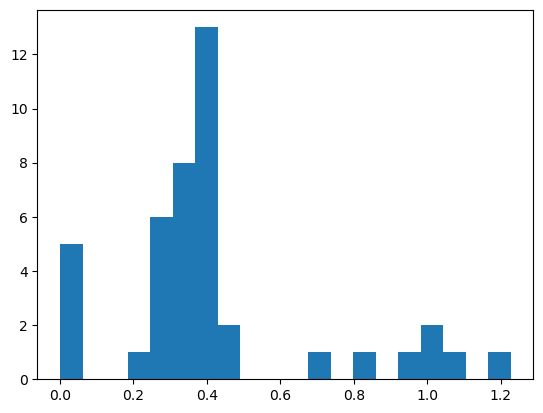

In [86]:
plt.hist(s, bins = 20)

In [57]:
np.isinf().all()

False

# Parameter swipe - # byproducts vs C sparsity

In [ ]:
n_cs_arr = np.arange(2, 22, 2)
sparsity_fraction = np.arange(0,1,0.1)
K_mean = -1
K_std = 2
iterations = 10
l0 = 0.1

In [ ]:
final_abundance_matrix2 = np.zeros((len(n_cs_arr), len(sparsity_fraction), iterations, 4))
richness_matrix2 = np.zeros((len(n_cs_arr), len(sparsity_fraction), iterations))
for ic, n_cs in enumerate(n_cs_arr):
    print(ic)
    for j, sp in enumerate(sparsity_fraction):
        k = 0
        while k < 10:
            R0 = np.zeros(n_cs) # Concentration of resources at t=0, (mass/volume)
            R0[0]=10
            l = l0*np.ones((n_species, n_cs)) # Leakage fractions
            N0 = np.ones(n_species)*1e-2
            
            C = np.zeros((n_species, n_cs))
            while C[:, 0].max()<0.2:
                C = np.random.lognormal(0, 1, (n_species, n_cs))
                C0 = (np.random.uniform(0,1, size = (n_species, n_cs))>sp).astype(int)
                C = C*C0
                # C = (C.T/C.sum(axis=1)).T
                C = C/C.max()

            D  = np.random.uniform(0, 1, size = (n_species, n_cs, n_cs))
            for i in range(n_cs):
                D[:,i,i] = 0
            for i in range(n_species):
                D[i,:,:] = D[i,:,:]/D[i, :,:].sum(axis = 0)
            D = np.transpose(D, (0, 2, 1))            
            K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
            c = CRM(n_species, n_cs, C, D = D, dilution_rate=0.1, l = l, K = K)
            
            time = 1000
            try:
                sol = c.run(time, N0, R0, dt = 0.1, method = 'BDF')
            except ValueError:
                continue
            else:
                if has_converged(c.N):
                    final_abundance_matrix2[ic,j,k,:] = c.N[-1,:]
                    richness_matrix2[ic,j,k] = richness(c.N)
                    k +=1


In [ ]:
# with open('C_sparsity_screen_N.npz', 'wb') as f:
#     np.savez(f, final_abundance_matrix2)
    

In [ ]:
# abundance_matrix = np.load('../parameter_swipe_c_sparsity/20240424-161917_final_abundance.npz')['arr_0']
abundance_matrix = np.load('../parameter_swipe_c_sparsity/20240501-015532_final_abundance.npz')['arr_0'] # No transfer
# abundance_matrix = np.load('../parameter_swipe_c_sparsity/20240501-015615_final_abundance.npz')['arr_0'] # Transfer


In [ ]:
richness_matrix2 = (abundance_matrix > 1e-5).sum(axis=3)
richness_matrix2 = richness_matrix2[:, ::-1,:]


In [ ]:
sns.heatmap(richness_matrix2.mean(axis=2).T, yticklabels=[f'{x:.2f}' for x in np.linspace(0,1,21)][::-1], cmap='Greens',
            cbar_kws={'label':'Mean richness'}, xticklabels = np.linspace(2, 30, 29, dtype=int)-1, vmin = 0, vmax = 4)
plt.xlabel('N byproducts')
plt.ylabel('Sparsity of C matrix')
plt.title('Richness on single carbon source with 4 species community')

In [ ]:
sol.nfev

In [ ]:
C[3]

In [ ]:
C = (C.T/C.sum(axis=1)).T

In [ ]:
plt.semilogy(c.R)

In [ ]:
A = np.ones(4)
B = 2*np.ones((3,4))

In [33]:
x = np.linspace(-10,6,100)


Text(0.5, 0, 'log10(K)')

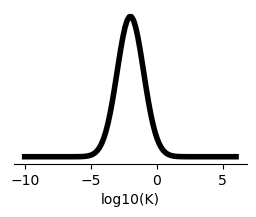

In [38]:
y = st.norm.pdf(x, -2, 1)
fig, ax = plt.subplots(1, figsize = (3,2))
ax.plot(x,y, lw = 4, c = 'k')
sns.despine(left = True)
ax.set(yticklabels=[], yticks=[])
plt.xlabel('log10(K)')

Text(0.5, 0, 'log10(K)')

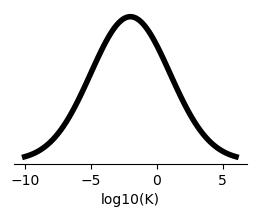

In [39]:
y = st.norm.pdf(x, -2, 3)
fig, ax = plt.subplots(1, figsize = (3,2))
ax.plot(x,y, lw = 4, c = 'k')
sns.despine(left = True)
ax.set(yticklabels=[], yticks=[])
plt.xlabel('log10(K)')